Disciplina: Tópicos Especiais em Lógica II (Aprendizado de Máquina Profundo - Deep Learning)

Período: 2025.2

Professor: Eliezer de Souza da Silva

Aluno: Davi Teixeira Silva

# Aula 4 - Laboratório: Construindo um MLP do Zero com NumPy

**Objetivo:** Implementar a mecânica do forward e backward pass para treinar um MLP em um problema não-linear, construindo um mini-framework modular com classes para camadas, custos, regularizadores e otimizadores.

---


## Parte 0: Configuração Inicial

Começamos importando as bibliotecas que usaremos hoje: NumPy para os cálculos, Matplotlib para visualização e Scikit-learn para gerar nossos datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles

# Configurações de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

## Parte 1: Fundamentos Teóricos (Revisão)

Antes de mergulhar no código, vamos recapitular a teoria que fundamenta nosso laboratório.

### O MLP como um Aproximador de Funções

Uma Feedforward Neural Network (FNN), ou Multilayer Perceptron (MLP), é uma função parametrizada $h(\mathbf{x}; \theta)$ que aprende um mapeamento de uma entrada $\mathbf{x}$ para uma saída $\hat{\mathbf{y}}$. Os parâmetros $\theta$ são os pesos $\mathbf{W}$ e vieses $\mathbf{b}$ de cada camada.

### O Ciclo de Treinamento
O treinamento ocorre em um ciclo iterativo:
1.  **Forward Pass:** Calculamos a predição da rede, $\hat{\mathbf{y}} = h(\mathbf{x}; \theta)$.
2.  **Cálculo do Custo:** Medimos o erro da predição usando uma função de custo, $J = L(\hat{\mathbf{y}}, \mathbf{y})$.
3.  **Backward Pass:** Usamos o algoritmo de Backpropagation para calcular o gradiente do custo em relação a cada parâmetro, $\nabla_{\theta} J$.
4.  **Atualização dos Pesos:** Ajustamos os parâmetros na direção oposta ao gradiente, $\theta \leftarrow \theta - \eta \nabla_{\theta} J$.

### O Backward Pass em Detalhe

O Backpropagation é a aplicação da regra da cadeia. A variável central é o "sinal de erro" $\boldsymbol{\delta}^{(l)} = \frac{\partial J}{\partial \mathbf{z}^{(l)}}$, que é o gradiente do custo em relação à entrada linear da camada $l$. Propagamos este sinal para trás:

-   **Erro na camada $l$ (a partir da $l+1$):** $\boldsymbol{\delta}^{(l)} = ( (\mathbf{W}^{(l+1)})^T \boldsymbol{\delta}^{(l+1)} ) \odot \sigma_l'(\mathbf{z}^{(l)})$
-   **Gradiente dos Pesos:** $\frac{\partial J}{\partial \mathbf{W}^{(l)}} = \boldsymbol{\delta}^{(l)} (\mathbf{a}^{(l-1)})^T$
-   **Gradiente do Viés:** $\frac{\partial J}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$

### Otimizador SGD e Regularização|

A otimização e a regularização são dois dos conceitos mais importantes no treinamento de redes neurais. Eles controlam *como* o modelo aprende e *quão bem* ele generaliza para novos dados.

---
#### Descida de Gradiente Estocástica (SGD)

A **Descida de Gradiente Estocástica (SGD)** é o algoritmo de otimização que impulsiona a maioria dos modelos de aprendizado profundo. É uma variação eficiente da Descida de Gradiente tradicional (Batch).

* **Batch Gradient Descent:** Calcula o gradiente da função de custo usando o **dataset de treinamento inteiro** a cada passo. Isso resulta em uma estimativa precisa da direção ideal para o mínimo, mas é computacionalmente inviável para os grandes datasets usados hoje.
* **Stochastic Gradient Descent:** Em vez de usar todos os dados, o SGD aproxima o gradiente usando **um único exemplo** de treinamento por vez. Isso torna cada atualização de peso extremamente rápida. A versão mais comum na prática é o **Mini-Batch SGD**, que calcula o gradiente sobre um pequeno lote (mini-batch) de dados (e.g., 32 a 256 exemplos).

A regra de atualização para o Mini-Batch SGD é:
$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta \left( \frac{1}{B} \sum_{n \in \mathcal{B}} \nabla_{\theta} L(h(\mathbf{x}_n; \theta), y_n) \right)$$
Onde $\mathcal{B}$ é o mini-batch de tamanho $B$. O gradiente calculado é uma estimativa "ruidosa" do gradiente real, mas essa aleatoriedade muitas vezes ajuda o modelo a escapar de mínimos locais rasos e a convergir mais rapidamente.

---
#### Regularização

A **regularização** é um conjunto de técnicas usadas para combater o **overfitting**. Overfitting ocorre quando um modelo se ajusta tão bem aos dados de treino (incluindo seu ruído) que perde a capacidade de generalizar para dados não vistos. A regularização alcança isso adicionando um termo de penalidade $\Omega(\theta)$ à função de custo, que desencoraja a complexidade do modelo.

O objetivo de otimização se torna:
$$J(\theta) = \hat{R}(h_\theta) + \lambda \Omega(\theta)$$

### Principais Tipos de Regularização

* **Regularização L2 (Weight Decay):**
    * **Penalidade:** $\Omega(\theta) = \frac{1}{2} \sum_i w_i^2 = \frac{1}{2} ||\mathbf{w}||_2^2$. Adiciona a soma dos quadrados dos pesos ao custo.
    * **Efeito:** Penaliza pesos grandes, incentivando o modelo a encontrar soluções com pesos menores e mais distribuídos. Isso resulta em uma função mais "suave" e menos propensa a se ajustar ao ruído. No passo de atualização do SGD, isso é equivalente a "decaimento de peso" (*weight decay*), onde os pesos são ligeiramente reduzidos a cada passo.

* **Regularização L1 (Lasso):**
    * **Penalidade:** $\Omega(\theta) = \sum_i |w_i| = ||\mathbf{w}||_1$. Adiciona a soma dos valores absolutos dos pesos.
    * **Efeito:** A regularização L1 tem a propriedade de poder levar alguns pesos a serem **exatamente zero**. Isso efetivamente remove conexões da rede, realizando uma forma de seleção de features automática e resultando em um modelo **esparso**.


## Parte 2: A Arquitetura do Nosso Código

Vamos encapsular cada componente em sua própria classe para criar um código modular e flexível.

In [2]:
class Differentiable:
  """Classe base para todas as funcionalidades diferenciáveis."""
  def forward(self, input_data):
    raise NotImplementedError
  def backward(self, output_grad):
    raise NotImplementedError
  def params(self):
    """Retorna uma lista vazia por padrão."""
    return []

class Layer(Differentiable):
  """Classe base para todas as camadas da rede neural com paraâmetros."""
  def forward(self, input_data):
    raise NotImplementedError
  def backward(self, output_grad):
    raise NotImplementedError
  def params(self):
    """Retorna os parâmetros e gradientes da camada."""
    return [], []



## Parte 3: Implementação Passo a Passo

Agora, vamos preencher o esqueleto do nosso mini-framework.

### 3.1 Camada Linear

In [3]:
class Linear(Layer):
  def __init__(self, input_size, output_size):
    # Inicialização dos parâmetros
    self.W = np.random.randn(input_size, output_size) * 0.1
    self.b = np.zeros((1, output_size))

    # Espaços reservados para gradientes
    self.input_data = None
    self.dW = np.zeros_like(self.W)
    self.db = np.zeros_like(self.b)

    # adicionados para facilitar a inspeção e visualização do modelo
    self.input_size = input_size
    self.output_size = output_size

  def forward(self, input_data):
    # TODO: Implementar o forward pass da camada linear.
    # Armazene a entrada em self.input_data para usar no backward pass.
    # Retorne a saída z = xW + b.
    self.input_data = input_data
    z = np.dot(input_data, self.W) + self.b
    return z

  def backward(self, output_grad):
    # TODO: Implementar o backward pass.
    # 1. Calcule o gradiente em relação aos pesos (dW) e armazene em self.dW.
    # 2. Calcule o gradiente em relação ao viés (db) e armazene em self.db.
    # 3. Calcule e retorne o gradiente em relação à entrada da camada (dJ/dx).

    # Gradiente dos pesos
    self.dW = np.dot(self.input_data.T, output_grad)
    # Gradiente dos vieses
    self.db = np.sum(output_grad, axis=0, keepdims=True)
    # Gradiente da entrada (para a camada anterior)
    input_grad = np.dot(output_grad, self.W.T)
    return input_grad

  def params(self):
    # Retorna os parâmetros e gradientes
    return [(self.W, self.dW), (self.b, self.db)]

### 3.2 Camada de Ativação (Sigmóide)

In [4]:
class Sigmoid(Differentiable):
  def __init__(self):
    self.output = None

  def forward(self, input_data):
    # TODO: Implementar o forward pass da sigmóide.
    # Armazene o resultado em self.output para usar no backward pass.
    # Aplica a função sigmóide
    self.output = 1 / (1 + np.exp(-input_data))
    return self.output

  def backward(self, output_grad):
    # TODO: Implementar o backward pass da sigmóide.
    # A derivada é output_grad * sigma'(z).
    # Propaga o gradiente
    sigmoid_derivative = self.output * (1 - self.output)
    input_grad = output_grad * sigmoid_derivative
    return input_grad

class ReLU(Differentiable):
  def __init__(self):
    self.output = None

  def forward(self, input_data):
    # TODO: Implementar o forward pass da ReLU.
    # Armazene o resultado em self.output para usar no backward pass.
    self.output = np.maximum(0, input_data)
    return self.output

  def backward(self, output_grad):
    # TODO: Implementar o backward pass da ReLU.
    # A derivada é output_grad * relu'(z).
    # relu_derivative = np.where(self.output > 0, 1, 0)
    # Propaga o gradiente
    relu_derivative = (self.output > 0).astype(float)
    input_grad = output_grad * relu_derivative
    return input_grad

### 3.3 Função de Custo (MSE)

In [5]:
class MSELoss(Differentiable):
  def forward(self, y_pred, y_true):
    # TODO: Implementar o cálculo do Erro Quadrático Médio (MSE).
    self.y_pred = y_pred
    self.y_true = y_true
    # Média dos quadrados das diferenças
    loss = np.mean((y_true - y_pred) ** 2)
    return loss

  def backward(self):
    # TODO: Implementar o cálculo do gradiente inicial do MSE.
    n = self.y_true.shape[0]  # número de amostras
    grad = (2 / n) * (self.y_pred - self.y_true)
    return grad

class BinaryCrossEntropyLoss(Differentiable):
  def forward(self, y_pred, y_true):
    # TODO: Implementar o cálculo da Entropia Cruzada Binária.
    epsilon = 1e-15 # para estabilidade numérica
    self.y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    self.y_true = y_true.astype(float)

    loss = -np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred))
    return loss

  def backward(self):
    # TODO: Implementar o cálculo do gradiente inicial da Entropia Cruzada Binária.
    n = self.y_true.shape[0]  # número de amostras
    eps = 1e-15
    grad = (1 / n) * ((1 - self.y_true) / (1 - self.y_pred + eps) - self.y_true / (self.y_pred + eps))
    return grad


### 3.4 Modelo Sequencial

In [6]:
class Sequential(Layer):
  # Recebe uma lista de camadas
  def __init__(self, layers):
    # Armazena essa lista internamente em self.layers
    self.layers = layers

  def forward(self, input_data):
    # Percorre todas as camadas na ordem em que foram adicionadas
    for layer in self.layers:
      input_data = layer.forward(input_data)
    # Retorna a saída final da rede
    return input_data

  def backward(self, output_grad):
    # Percorre de trás pra frente (reversed), propagando os gradientes
    # Esse processo é a retropropagação do erro (backpropagation)
    for layer in reversed(self.layers):
      output_grad = layer.backward(output_grad)
    return output_grad

  def params(self):
    parameters = []
    # Coleta todos os parâmetros e gradientes de cada camada que tiver parâmetros
    for layer in self.layers:
      if hasattr(layer, 'params'):
        parameters.extend(layer.params())
    return parameters

  def __repr__(self):
    desc = "Sequential(\n"
    for i, layer in enumerate(self.layers):
      desc += f"  ({i}): {layer.__class__.__name__}("
      # Mostrar dimensões se for linear
      if isinstance(layer, Linear):
        desc += f"in_features={layer.input_size}, out_features={layer.output_size}"
      desc += ")\n"
    desc += ")"
    return desc

### 3.5 O Otimizador (SGD)

In [7]:
class SGD:
  def __init__(self, model, learning_rate):
    # Guarda o modelo (do tipo Sequential).
    # E a taxa de aprendizado que será usada para ajustar os pesos.
    self.model = model
    self.learning_rate = learning_rate

  def step(self):
    # TODO: Itere sobre os parâmetros do modelo (use model.params())
    # e aplique a regra de atualização da descida de gradiente.
    for param, grad in self.model.params():
      param -= self.learning_rate * grad

  def zero_grad(self):
    # TODO: Itere sobre os parâmetros do modelo e zere seus gradientes.
    for param, grad in self.model.params():
      grad.fill(0)

#### 3.5.1 Regularização (L2)



In [8]:
class L2Regularization(Differentiable):
  def __init__(self, model, lambda_, eta):
    self.model = model
    self.lambda_ = lambda_
    self.eta = eta

  def forward(self, input_data=None):
    # TODO: Implementar o forward pass da regularização L2.
    reg_loss = 0.0
    for layer in self.model.layers:
      for (param, grad) in layer.params():
        # Aplicando somente em pesos (não em biases)
        if param.ndim > 1:
          reg_loss += np.sum(param ** 2)
      return 0.5 * self.lambda_ * reg_loss

  def backward(self, output_grad=None):
    # TODO: Implementar o backward pass da regularização L2.
    for layer in self.model.layers:
      for (param, grad) in layer.params():
        if param.ndim > 1: # Só pesos
          grad += self.lambda_ * param

  def step(self):
    # TODO: Implementar o passo de atualização dos pesos com regularização L2.
    for layer in self.model.layers:
      for (param, grad) in layer.params():
        if param.ndim > 1:
          param *= (1 - self.eta * self.lambda_)

### 3.6 Treinando o Modelo

Agora, vamos usar nossas classes para treinar um MLP no dataset `make_moons`.

In [9]:
# Gerar dados
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

# Definir a arquitetura do modelo
model = Sequential([
    Linear(2, 16),
    Sigmoid(),
    Linear(16, 1),
    Sigmoid()
])

# Instanciar os componentes
loss_fn = MSELoss()
optimizer = SGD(model, learning_rate=0.1)

epochs = 5000
loss_history = []

# Loop de Treinamento
for epoch in range(epochs):
    # TODO: Preencha o loop de treinamento usando os métodos das suas classes.
    # 1. Forward pass
    y_pred = model.forward(X)

    # 2. Calcular o custo
    loss = loss_fn.forward(y_pred, y)
    loss_history.append(loss)

    # 3. Zerar gradientes anteriores
    # Chame o método do otimizador
    optimizer.zero_grad()

    # 4. Backward pass
    grad_initial = loss_fn.backward() # Obtenha o gradiente inicial da função de custo
    # Chame o backward do modelo
    model.backward(grad_initial)

    # 5. Atualizar os pesos
    # Chame o método do otimizador
    optimizer.step()

    # Monitorar o progresso
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')

Epoch [500/5000], Loss: 0.1719
Epoch [1000/5000], Loss: 0.1157
Epoch [1500/5000], Loss: 0.0998
Epoch [2000/5000], Loss: 0.0931
Epoch [2500/5000], Loss: 0.0904
Epoch [3000/5000], Loss: 0.0892
Epoch [3500/5000], Loss: 0.0887
Epoch [4000/5000], Loss: 0.0884
Epoch [4500/5000], Loss: 0.0882
Epoch [5000/5000], Loss: 0.0881


### 3.7 Visualização da Fronteira

Vamos plotar a fronteira de decisão para ver o que nosso modelo aprendeu.

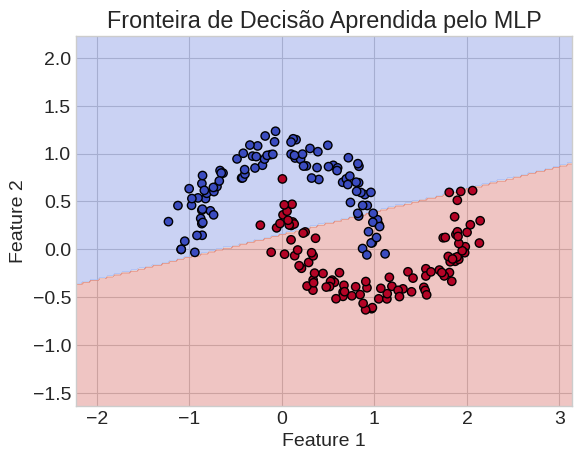

In [10]:
def plot_decision_boundary(model, X, y, h=0.02):
  # Define os limites do gráfico
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

  # Criar uma grade de pontos
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

  # Juntar os pontos da grade em um array (cada linha é um ponto 2D)
  grid = np.c_[xx.ravel(), yy.ravel()]

  # Fazer a previsão para cada ponto da grade
  Z = model.forward(grid)

  # Caso a saída seja contínua (ex: sigmoid), converte para classe 0/1
  if Z.ndim > 1 and Z.shape[1] == 1:
    Z = (Z > 0.5).astype(int)

  # Redimensionar para o formato da grade
  Z = Z.reshape(xx.shape)

  # Plotar as regiões de decisão
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

  # Plota os pontos de treino originais
  plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap=plt.cm.coolwarm)
  plt.title('Fronteira de Decisão Aprendida pelo MLP')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.show()

plot_decision_boundary(model, X, y)

### Exercício 4: Inspecionando a Rede

Tão importante quanto construir um modelo é ser capaz de inspecioná-lo. Isso nos ajuda a depurar, entender a complexidade e garantir que a arquitetura que montamos é realmente a que pretendíamos.

**4.1. Visualizando a Estrutura em Texto**

Uma representação em texto é a forma mais simples e direta de verificar a estrutura de um modelo. Em frameworks como PyTorch, quando você imprime um objeto de modelo, um método especial (`__repr__`) é chamado para gerar uma descrição legível.

**Tarefa:** Adicione o método `__repr__` à sua classe `Sequential`. Ele deve iterar sobre as camadas e construir uma string que lista cada camada com seu índice e uma breve descrição (e.g., `Linear(in=2, out=16)`).

**4.2. Visualizando a Estrutura Graficamente**

Uma visualização gráfica pode oferecer uma intuição ainda melhor sobre o fluxo de dados.

**Tarefa:** Crie uma função que receba seu modelo `Sequential` e use o `matplotlib` para desenhar um diagrama da arquitetura. Uma sugestão é representar cada camada como um bloco retangular, mostrando o tipo de camada e a forma dos dados que fluem entre elas.


**4.3. Visualizando a Função de Ativação**

É uma boa prática de sanidade verificar se nossas implementações matemáticas estão corretas.

**Tarefa:**  Crie uma função simples que receba um objeto de camada de ativação (e.g., Sigmoid()) e plote sua saída e sua derivada para um intervalo de entradas (e.g., de -5 a 5). Verifique se os gráficos correspondem às formas teóricas.

#### 4.1 Visualizando a Estrutura em Texto

In [11]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=16)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=1)
  (3): Sigmoid()
)


#### 4.2 Visualizando a Estrutura Graficamente

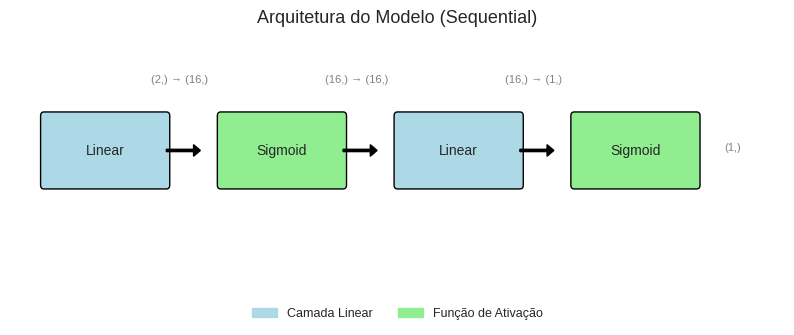

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def plot_model_architecture(model, input_shape):
  fig, ax = plt.subplots(figsize=(10, 3))
  ax.axis('off')
  x = 0
  y = 0

  prev_shape = input_shape # Forma de entrada inicial
  arrow_offset = 0.4

  for i, layer in enumerate(model.layers):
    layer_name = layer.__class__.__name__

    # Define o tamanho e a cor do bloco
    width = 1.8
    height = 0.9
    color = '#add8e6' if "Linear" in layer_name else '#90ee90'

    # Desenha o retângulo da camada
    rect = mpatches.FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.05", edgecolor='black', facecolor=color)

    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, layer_name, ha='center', va='center', fontsize=10)

    # Calcula a forma de saída
    if isinstance(layer, type(model.layers[0])) and hasattr(layer, "output_size"):
      next_shape = (layer.output_size,)
    else:
      next_shape = prev_shape # ativação não muda forma

    # Adicionar seta e shape
    if i < len(model.layers) - 1:
      arrow = mpatches.FancyArrow(x + width, y + height/2, 0.4, 0, width=0.03, head_width=0.15, head_length=0.1, color='black')
      ax.add_patch(arrow)
      ax.text(x + width + 0.2, y + height + arrow_offset, f"{prev_shape} → {next_shape}", ha='center', va='bottom', fontsize=8, color='gray')
    else:
      # saída final
      ax.text(x + width + 0.4, y + height/2, f"{next_shape}", fontsize=8, color='gray')

    prev_shape = next_shape
    x += width + 0.8

  # Adicionar legenda
  linear_patch = mpatches.Patch(color='#add8e6', label='Camada Linear')
  activation_patch = mpatches.Patch(color='#90ee90', label='Função de Ativação')
  ax.legend(handles=[linear_patch, activation_patch], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9, frameon=False)

  plt.xlim(-0.5, x + 0.5)
  plt.ylim(-1, 2)
  plt.title("Arquitetura do Modelo (Sequential)", fontsize=13)
  plt.show()

plot_model_architecture(model, input_shape=(2,))


#### 4.3 Visualização da Função de Ativação

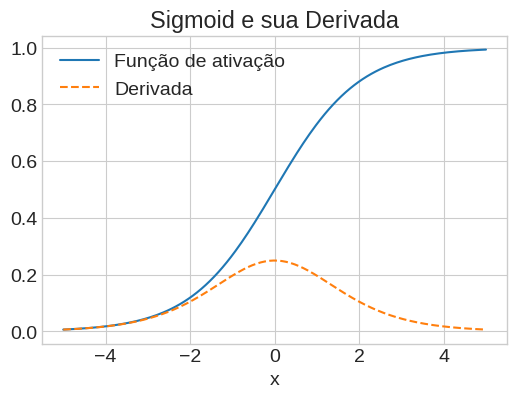

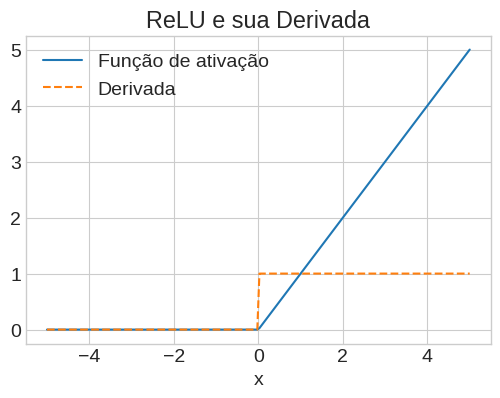

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_activation_function(activation_layer, name='Activation'):
  x = np.linspace(-5, 5, 200).reshape(-1, 1)
  y = activation_layer.forward(x)
  dy = activation_layer.backward(np.ones_like(x))  # derivada

  plt.figure(figsize=(6, 4))
  plt.plot(x, y, label='Função de ativação')
  plt.plot(x, dy, label='Derivada', linestyle='--')
  plt.title(f'{name} e sua Derivada')
  plt.xlabel('x')
  plt.legend()
  plt.grid(True)
  plt.show()

plot_activation_function(Sigmoid(), 'Sigmoid')
plot_activation_function(ReLU(), 'ReLU')


### Exercício 5: Testando outros datasets e variações na arquitetura

Um bom modelo deve ser flexível. Vamos agora testar nosso framework em outros problemas de classificação clássicos para ver como ele se comporta e a importância de ajustar a arquitetura.

**A Tarefa:**

Modifique sua rede e os hiperparâmetros de treinamento (taxa de aprendizado, número de épocas, número de neurônios/camadas) para resolver os seguintes problemas:

1.  **Círculos Concêntricos:** Use `make_circles` do scikit-learn.
2.  **XOR:** Crie os 4 pontos de dados do problema XOR manualmente.
3.  **MNIST (dois dígitos):** Carregue o dataset MNIST, filtre para manter apenas dois dígitos (e.g., 3 e 8), e treine um classificador binário.

Para cada dataset, o objetivo é gerar uma visualização da fronteira de decisão que separe as classes corretamente. Observe como diferentes arquiteturas podem ser necessárias para cada problema.

[Duas Luas] Epoch [1000/5000], Loss: 0.1220
[Duas Luas] Epoch [2000/5000], Loss: 0.0940
[Duas Luas] Epoch [3000/5000], Loss: 0.0894
[Duas Luas] Epoch [4000/5000], Loss: 0.0885
[Duas Luas] Epoch [5000/5000], Loss: 0.0882


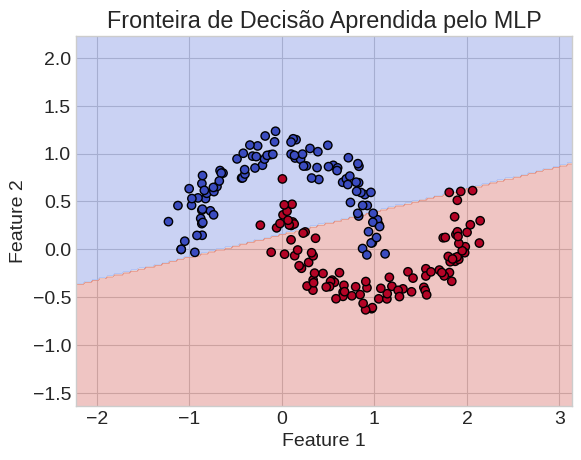

[Círculos Concêntricos] Epoch [1600/8000], Loss: 0.2500
[Círculos Concêntricos] Epoch [3200/8000], Loss: 0.2500
[Círculos Concêntricos] Epoch [4800/8000], Loss: 0.2500
[Círculos Concêntricos] Epoch [6400/8000], Loss: 0.2500
[Círculos Concêntricos] Epoch [8000/8000], Loss: 0.2500


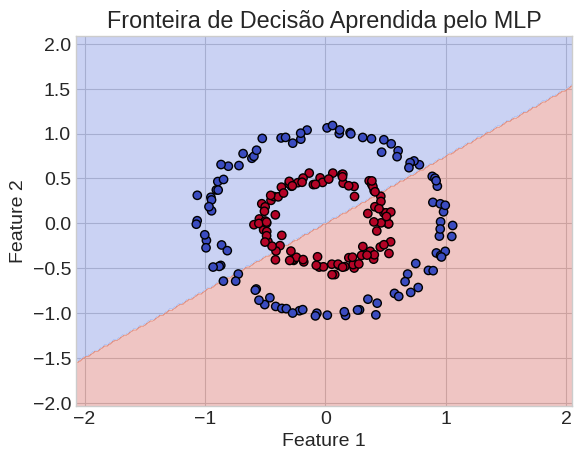

[Problema XOR] Epoch [2000/10000], Loss: 0.1259
[Problema XOR] Epoch [4000/10000], Loss: 0.1255
[Problema XOR] Epoch [6000/10000], Loss: 0.1253
[Problema XOR] Epoch [8000/10000], Loss: 0.1252
[Problema XOR] Epoch [10000/10000], Loss: 0.1252


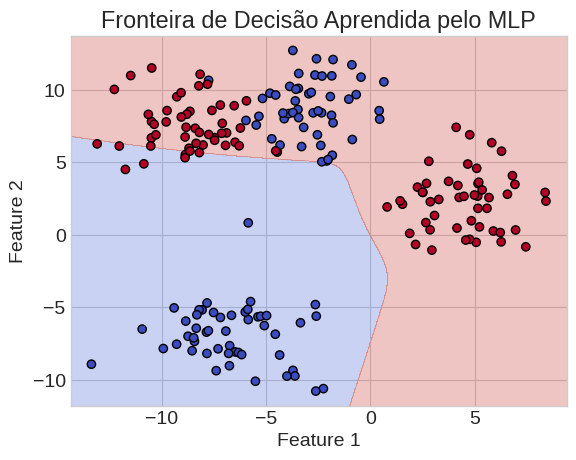

[MNIST (0 e 1)] Epoch [200/1000], Loss: 0.2369
[MNIST (0 e 1)] Epoch [400/1000], Loss: 0.1519
[MNIST (0 e 1)] Epoch [600/1000], Loss: 0.0310
[MNIST (0 e 1)] Epoch [800/1000], Loss: 0.0126
[MNIST (0 e 1)] Epoch [1000/1000], Loss: 0.0079


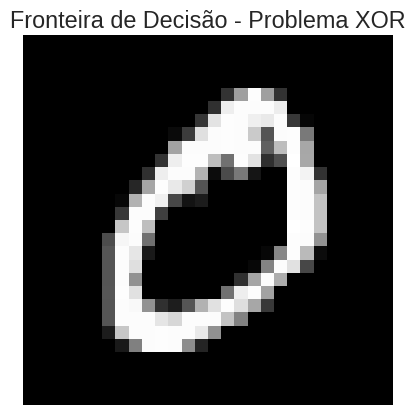

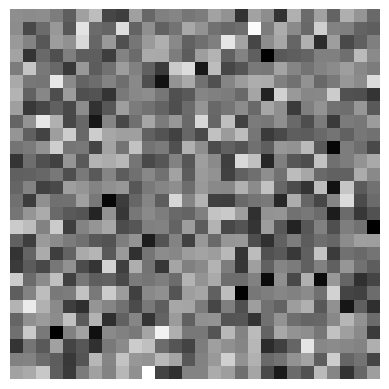

In [15]:
from sklearn.datasets import make_moons, make_circles, make_blobs
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np


def train_and_plot(X, y, hidden_layers=[16], lr=0.1, epochs=5000, title=""):
  # Garantir o formato correto
  if y.ndim == 1:
    y = y.reshape(-1, 1)

  # Criar arquitetura dinamicamente
  layers = []
  input_dim = X.shape[1]

  for h in hidden_layers:
    layers.append(Linear(input_dim, h))
    layers.append(Sigmoid())
    input_dim = h

  # Saída binária
  layers.append(Linear(input_dim, 1))
  layers.append(Sigmoid())

  model = Sequential(layers)

  # Função de perda e otimizadpr
  loss_fn = MSELoss()
  optimizer = SGD(model, learning_rate=lr)

  # Treinamento
  loss_history = []
  for epoch in range(epochs):
    # Forward
    y_pred = model.forward(X)

    # Custo
    loss = loss_fn.forward(y_pred, y)
    loss_history.append(loss)

    # Zeros
    optimizer.zero_grad()

    # Backward
    grad_initial = loss_fn.backward()
    model.backward(grad_initial)

    # Atualização
    optimizer.step()

    if (epoch + 1) % (epochs // 5) == 0:
      print(f"[{title}] Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}")

  if X.shape[1] == 2:
    # Plotar fronteira de decisão
    plot_decision_boundary(model, X, y, h=0.02)
    plt.title(f"Fronteira de Decisão - {title}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

  return model, loss_history

# Two Moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
model_moons, loss_moons = train_and_plot(X_moons, y_moons, hidden_layers=[16], lr=0.1, epochs=5000, title="Duas Luas")


# Circles
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
model_circles, loss_circles = train_and_plot(X_circles, y_circles, hidden_layers=[8, 8], lr=0.5, epochs=8000, title="Círculos Concêntricos")


# XOR
X_xor, y = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=2.0, random_state=42)
y_xor=y%2

model_xor, loss_xor = train_and_plot(X_xor, y_xor, hidden_layers=[4], lr=0.8, epochs=10000, title="Problema XOR")

del model_moons
del loss_moons
del model_circles
del loss_circles
del model_xor
del loss_xor

# Carregar o dataset MNIST
train_data = MNIST(root='./data', train=True, download=True, transform=ToTensor())

# Filtrar para manter apenas os dígitos 0 e 1
mask = (train_data.targets == 0) | (train_data.targets == 1)
data = train_data.data[mask].float() / 255.0  # Normalizar para [0, 1]
labels = train_data.targets[mask].numpy().reshape(-1, 1)

# Flatten das imagens (28x28 -> 784)
X_mnist = data.reshape(-1, 28 * 28).numpy()
y_mnist = labels

model_mnist, loss_mnist = train_and_plot(X_mnist, y_mnist, hidden_layers=[32, 16], lr=0.1, epochs=1000, title="MNIST (0 e 1)")

# Função para normalizar e remodelar para exibição
def prep_for_display(pc_vector, img_size=(28, 28)):
    img = pc_vector.reshape(img_size[0], img_size[1])
    # Normalizar para o intervalo [0, 1] para visualização
    img = (img - img.min()) / (img.max() - img.min())
    return img

# Função pra mostrar uma imagem da saida ou layers da rede neural
def show_image(pc_vector):
    img = prep_for_display(pc_vector)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

# Mostrar uma amostra real do dataset
show_image(X_mnist[0])  # mostra a primeira imagem (0 ou 1)

# Ou visualizar os pesos da primeira camada do modelo treinado
first_layer = model_mnist.layers[0]
show_image(first_layer.W[:, 0])  # visualiza o primeiro neurônio

### Exercício 6: Adaptando a Rede para Regressão

Redes neurais não servem apenas para classificação. Com algumas modificações simples, podemos usá-las para aproximar funções contínuas e resolver problemas de regressão.

**A Tarefa:**

Modifique sua rede e o loop de treinamento para resolver um problema de regressão, ajustando uma curva a dados ruidosos.

**Mudanças Necessárias:**

1.  **Dados:** Gere dados a partir de uma função complexa com ruído Gaussiano. Por exemplo, $y = 6\sin(x)+8\cos(x)+x^2 + \text{ruído}$. Para um desafio extra, crie uma função que gera uma função-alvo aleatória a cada vez, escolhendo termos simples e coeficientes aleatórios.

2.  **Arquitetura:** A mudança mais importante é na camada de saída. Como a saída do modelo não é mais uma probabilidade no intervalo [0, 1], a ativação Sigmóide final deve ser **removida**. A saída da última camada `Linear` será diretamente a sua predição $\hat{y}$. As camadas internas podem continuar usando ativações como `ReLU` ou `Sigmoid`.

3.  **Custo:** A função de custo deve ser a `MSELoss` (Erro Quadrático Médio), que é a escolha padrão para regressão, pois corresponde à suposição de uma verossimilhança Gaussiana para o ruído dos dados.

In [16]:
import numpy as np
import matplotlib.pyplot as plt


class RandomRegressionData:
    def __init__(self):
        self.base_functions = {
        'sin': np.sin,
        'cos': np.cos,
        'square': np.square,
        'cube': lambda x: x**3,
        'linear': lambda x: x,
        'abs': np.abs,
        'sqrt_abs': lambda x: np.sqrt(np.abs(x)),
        'log_abs': lambda x: np.log(np.abs(x) + 1e-5)  # Evitar log(0)
        }

    def generate_random_regression_data(self, n_samples=200, noise=0.2, x_range=(-1, 4)):
        """
        Gera dados para um problema de regressão a partir de uma função-alvo
        aleatoriamente construída.

        A função-alvo é uma combinação linear de um subconjunto aleatório de
        funções de base, com coeficientes aleatórios.

        Args:
            n_samples (int): O número de pontos de dados a serem gerados.
            noise (float): A magnitude (desvio padrão) do ruído Gaussiano adicionado.
            x_range (tuple): O intervalo (min, max) para a variável de entrada x.

        Returns:
            tuple: Uma tupla contendo:
                - X (np.array): O vetor de entrada de formato (n_samples, 1).
                - y (np.array): O vetor de saída com ruído, de formato (n_samples, 1).
                - true_function_str (str): Uma string descrevendo a função real gerada.
        """
        # Gerar o domínio de entrada X
        X = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1, 1)

        # Inicializar a saída y e a string da função
        y_true = np.zeros_like(X)
        true_function_str = "y = "

        # Escolher um número aleatório de termos para a função (entre 2 e 4)
        num_terms = np.random.randint(2, 5)

        # Selecionar um subconjunto aleatório de funções sem reposição
        chosen_funcs = np.random.choice(list(self.base_functions.keys()), num_terms, replace=False)

        terms = []
        for i, func_name in enumerate(chosen_funcs):
            # Gerar um coeficiente aleatório
            coeff = np.random.uniform(-1, 3)

            # Obter a função do dicionário
            func = self.base_functions[func_name]

            # Adicionar o termo à saída e à string
            y_true += coeff * func(X)
            terms.append((coeff, func_name))

            sign = "+" if coeff > 0 else "-"
            if i > 0:
                true_function_str += f" {sign} {abs(coeff):.2f} * {func_name}(x)"
            else:
                # Para o primeiro termo, não mostramos o sinal de +
                true_function_str += f"{coeff:.2f} * {func_name}(x)"

        # Adicionar ruído Gaussiano
        y_noisy = y_true + np.random.randn(n_samples, 1) * noise

        return X, y_noisy, true_function_str, terms

    def evaluate_function(self, X, terms):
        """
        Avalia a função real gerada em um conjunto de pontos X.

        Args:
            X (np.array): O vetor de entrada de formato (n_samples, 1).
            terms (list): A lista de termos (coeficiente, nome_da_função) que definem a função.

        Returns:
            np.array: O vetor de saída avaliado, de formato (n_samples, 1).
        """
        y_true = np.zeros_like(X)
        for coeff, func_name in terms:
            func = self.base_functions[func_name]
            y_true += coeff * func(X)
        return y_true


Função alvo: y = 2.82 * sin(x) + 1.97 * cube(x) - 0.11 * cos(x) + 0.49 * linear(x)
Função gerada: y = 2.82 * sin(x) + 1.97 * cube(x) - 0.11 * cos(x) + 0.49 * linear(x)


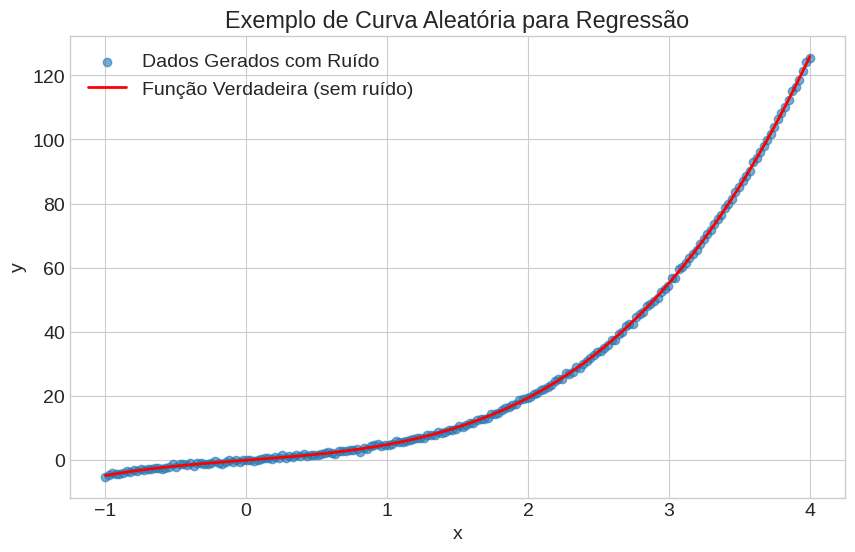

In [28]:

# Instanciar a classe
data_generator = RandomRegressionData()
# Gerar dados
X_data, y_data, func_str, func_terms = data_generator.generate_random_regression_data(n_samples=200, noise=0.3)
print("Função alvo:", func_str)

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, alpha=0.6, label='Dados Gerados com Ruído')

y_true = data_generator.evaluate_function(X_data, func_terms)
plt.plot(X_data, y_true, 'r-', lw=2, label='Função Verdadeira (sem ruído)')

plt.title("Exemplo de Curva Aleatória para Regressão")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
print("Função gerada:", func_str)
plt.show()


#### Treinar a rede (versão regressão)

Epoch [600/3000] - Loss: 20.0129
Epoch [1200/3000] - Loss: 8.0664
Epoch [1800/3000] - Loss: 4.5253
Epoch [2400/3000] - Loss: 2.9763
Epoch [3000/3000] - Loss: 2.1515


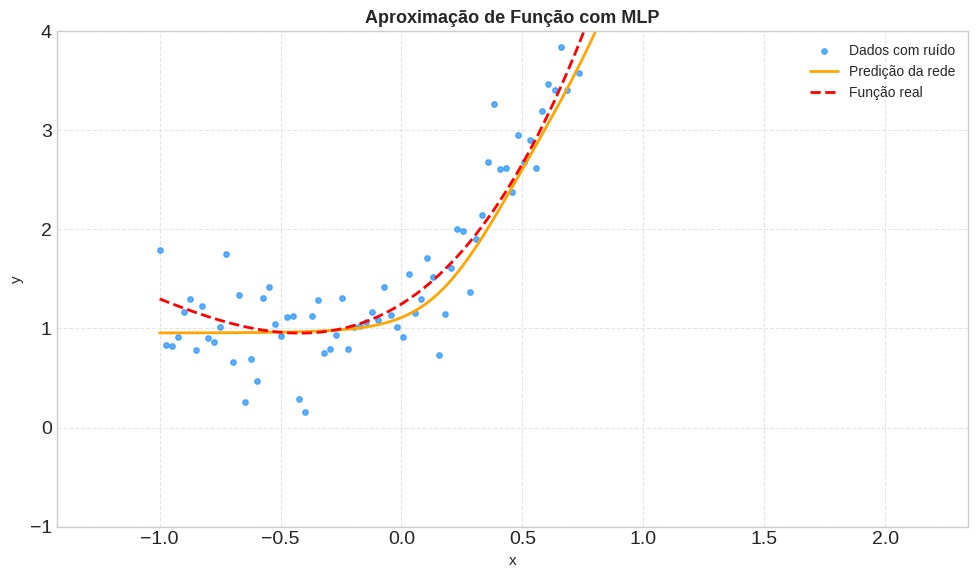

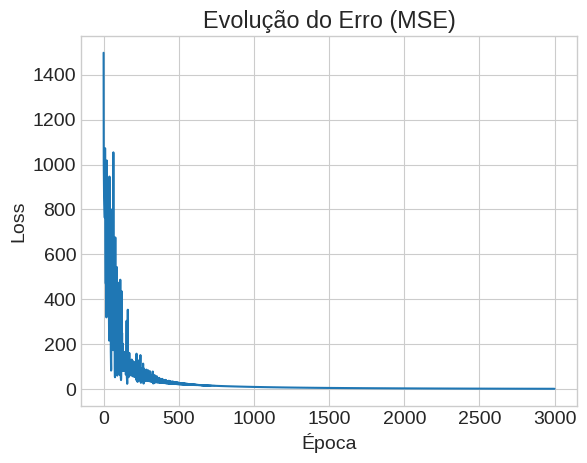

In [26]:
# =============================
# Treinamento da rede MLP
# =============================

def train_regression(X, y, hidden_layers=[32, 16], lr=0.05, epochs=2000):

    # Garantir formato correto
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Criar rede dinâmica
    layers = []
    input_dim = X.shape[1]

    for h in hidden_layers:
        layers.append(Linear(input_dim, h))
        layers.append(Sigmoid())   # pode trocar por ReLU se tiver implementada
        input_dim = h

    # Camada de saída SEM Sigmoid
    layers.append(Linear(input_dim, 1))

    model = Sequential(layers)
    loss_fn = MSELoss()
    optimizer = SGD(model, learning_rate=lr)

    losses = []
    for epoch in range(epochs):
        # Forward
        y_pred = model.forward(X)
        loss = loss_fn.forward(y_pred, y)
        losses.append(loss)

        # Backward
        optimizer.zero_grad()
        grad = loss_fn.backward()
        model.backward(grad)
        optimizer.step()

        # Log periódico
        if (epoch + 1) % (epochs // 5) == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss:.4f}")

    return model, losses

# Treinar modelo
model_reg, loss_reg = train_regression(X_data, y_data, hidden_layers=[32, 16], lr=0.05, epochs=3000)

# =============================
# Avaliação e visualização
# =============================

# Predição do modelo
y_pred = model_reg.forward(X_data)

plt.figure(figsize=(10,6))

# Plot dos dados
plt.scatter(X_data, y_data, color='dodgerblue', s=15, alpha=0.7, label='Dados com ruído')

# Linha da predição
plt.plot(X_data, y_pred, color='orange', linewidth=2, label='Predição da rede')

# Linha da função verdadeira
plt.plot(X_data, data_generator.evaluate_function(X_data, func_terms), color='red', linestyle='--', linewidth=2, label='Função real')
plt.title("Aproximação de Função com MLP", fontsize=13, weight='bold')
plt.xlabel("x", fontsize=11)
plt.ylabel("y", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(X.min() - 0.2, X.max() + 0.2)
plt.ylim(y.min() - 1, y.max() + 1)

# Ajustar o aspecto para parecer mais equilibrado
plt.gca().set_aspect('auto')

plt.tight_layout()
plt.show()

# Curva de perda
plt.plot(loss_reg)
plt.title("Evolução do Erro (MSE)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

### Exercício 7: Compare sua implementação com PyTorch ou JAX

Agora que você construiu e treinou um framework do zero, é hora de apreciar o poder e a conveniência das bibliotecas modernas de Deep Learning.

**A Tarefa:**

Escolha um dos problemas de classificação tratados hoje (e.g., "Duas Luas" ou "Círculos Concêntricos") e desenvolva uma nova implementação para resolvê-lo usando **PyTorch** ou **JAX**.

**O que comparar:**

* **Complexidade do Código:** Compare a quantidade de código necessária para definir o modelo, o custo e o loop de treinamento na sua implementação NumPy vs. a do framework.
* **Facilidade de Uso:** Quão mais fácil foi gerenciar os gradientes, os parâmetros e a atualização dos pesos?
* **Performance:** Houve diferença na velocidade de treinamento ou na acurácia final do modelo?

O objetivo é refletir sobre as abstrações que os frameworks modernos fornecem e entender o que está acontecendo "por baixo dos panos" quando você chama funções como `loss.backward()` e `optimizer.step()`.

Epoch [200/1000] - Loss: 0.2842
Epoch [400/1000] - Loss: 0.2289
Epoch [600/1000] - Loss: 0.1584
Epoch [800/1000] - Loss: 0.1147
Epoch [1000/1000] - Loss: 0.0975

Acurácia no conjunto de teste: 98.00%


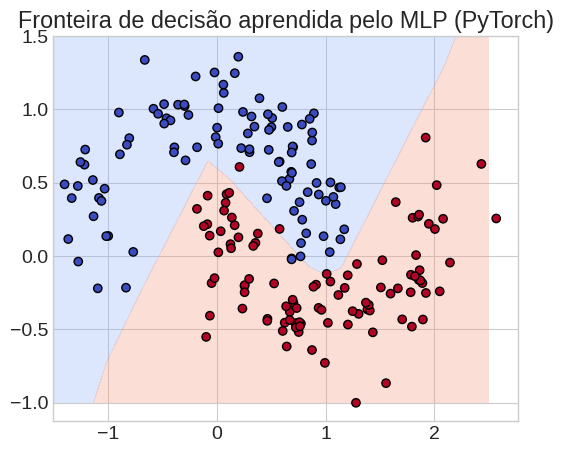

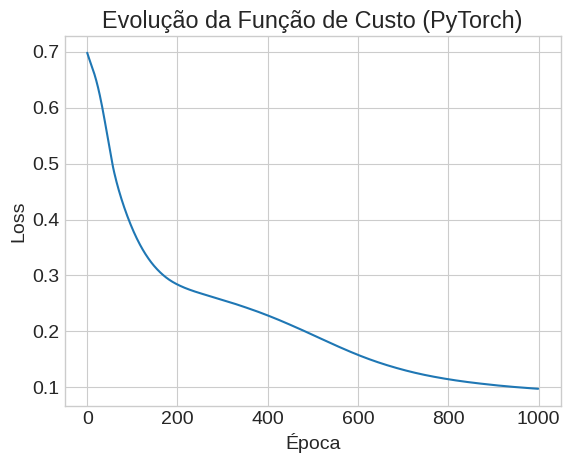

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================
# 1. Gerar dados
# ==========================
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Converter para tensores do PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ==========================
# 2. Definir o modelo
# ==========================
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(2, 16),
      nn.ReLU(),
      nn.Linear(16, 8),
      nn.ReLU(),
      nn.Linear(8, 1),
      nn.Sigmoid()
    )

  def forward(self, x):
    return self.net(x)

model = MLP()

# ==========================
# 3. Definir função de perda e otimizador
# ==========================
criterion = nn.BCELoss()              # Binary Cross-Entropy
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ==========================
# 4. Treinamento
# ==========================
epochs = 1000
losses = []

for epoch in range(epochs):
  # Forward
  y_pred = model(X_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.item())

  # Backward
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Log
  if (epoch + 1) % 200 == 0:
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

# ==========================
# 5. Avaliação
# ==========================
with torch.no_grad():
  y_pred_test = model(X_test)
  acc = ((y_pred_test > 0.5) == y_test).float().mean().item()

print(f"\nAcurácia no conjunto de teste: {acc*100:.2f}%")

# ==========================
# 6. Visualização da fronteira de decisão
# ==========================
import numpy as np

xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1, 1.5, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
  Z = model(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test.squeeze(), cmap='coolwarm', edgecolors='k')
plt.title("Fronteira de decisão aprendida pelo MLP (PyTorch)")
plt.show()

# ==========================
# 7. Curva de perda
# ==========================
plt.plot(losses)
plt.title("Evolução da Função de Custo (PyTorch)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()


## Conclusão

Ao comparar as duas implementações, percebi que o PyTorch realmente simplifica muito o processo. Enquanto na versão com NumPy eu precisei fazer tudo manualmente — desde o cálculo do forward e backward até a atualização dos pesos —, no PyTorch boa parte disso já vem pronta. O `loss.backward()` e o `optimizer.step()` cuidam de toda a parte mais trabalhosa, o que deixa o código bem mais curto e fácil de entender.

Outro ponto que me chamou atenção foi a performance: o PyTorch roda bem mais rápido e ainda pode usar GPU, o que faz muita diferença em redes maiores. Além disso, o código fica mais organizado e limpo, com menos linhas e mais foco na lógica do modelo.

Mesmo assim, construir a rede na mão com NumPy foi muito importante pra entender o que está acontecendo por trás dessas funções automáticas. Ter implementado o backpropagation e o update dos pesos na prática ajudou a fixar de verdade como a rede aprende. No fim das contas, o PyTorch é ótimo pra usar no dia a dia, mas o aprendizado com NumPy foi o que me fez entender de fato os fundamentos das redes neurais.